In [82]:
import yfinance as yf
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

In [83]:
# Download real market data
df = yf.download(['AAPL', 'SPY'], start='2020-01-01')

[*********************100%***********************]  2 of 2 completed


In [45]:
df.head(10)

Price,Adj Close,Close,High,Low,Open,Volume
Ticker,AAPL,AAPL,AAPL,AAPL,AAPL,AAPL
Date,,,,,,
2010-01-04,6.412383,7.643214,7.660714,7.585000,7.622500,493729600
2010-01-05,6.423468,7.656429,7.699643,7.616071,7.664286,601904800
2010-01-06,6.321294,7.534643,7.686786,7.526786,7.656429,552160000
2010-01-07,6.309609,7.520714,7.571429,7.466071,7.562500,477131200
2010-01-08,6.351558,7.570714,7.571429,7.466429,7.510714,447610800
2010-01-11,6.295529,7.503929,7.607143,7.444643,7.600000,462229600
2010-01-12,6.223916,7.418571,7.491786,7.372143,7.471071,594459600
2010-01-13,6.311707,7.523214,7.533214,7.289286,7.423929,605892000


In [88]:
# Extract the right prices
prices = df['Close'][['AAPL', 'SPY']]
prices = prices.dropna()

In [89]:
# Convert prices to returns
returns = prices.pct_change().dropna()

In [90]:
# Define strategy. This is a simple long/short spread. I.e long AAPL, short SPY, half-sized risk
netRet = (returns['AAPL'] - returns['SPY']) / 2

In [91]:
# Build cumulative returns
cumret = (1 + netRet).cumprod() - 1

In [93]:
# Define our calculate max drawdown function
def calculateMaxDD(cumret):
    cumret = np.array(cumret)

    hwm = np.maximum.accumulate(cumret)
    drawdown = (1 + cumret) / (1 + hwm) - 1

    maxDD = drawdown.min()
    end = np.argmin(drawdown)

    if end == 0:
        start = 0
    else:
        start = np.argmax(cumret[:end])

    return maxDD, start, end

In [95]:
# Plugging data into our function
maxDD, start, end = calculateMaxDD(cumret.values)

start_date = cumret.index[start]
end_date = cumret.index[end]

# Printing our results
print("Max Drawdown:", maxDD)
print("Start:", start_date)
print("End:", end_date)

Max Drawdown: -0.1394664470125978
Start: 2023-06-30 00:00:00
End: 2024-04-08 00:00:00


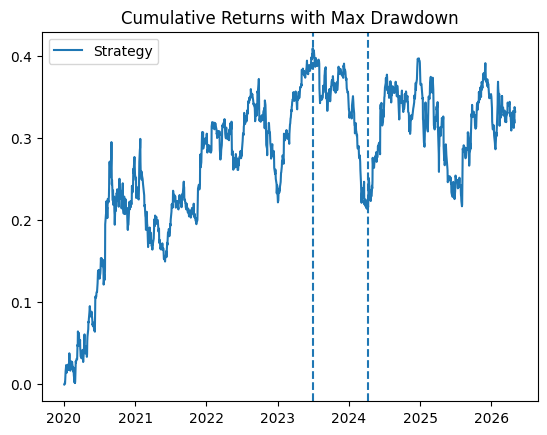

In [96]:
plt.figure()
plt.plot(cumret, label='Strategy')
plt.axvline(start_date, linestyle='--')
plt.axvline(end_date, linestyle='--')
plt.legend()
plt.title('Cumulative Returns with Max Drawdown')
plt.show()

In [97]:
# Calculate the Sharpe Ratio
sharpe = np.sqrt(252) * netRet.mean() / netRet.std()
print("Sharpe:", sharpe)

Sharpe: 0.49942390399359843


In [99]:
# This tells you what market regime broke your strategy
cumret.loc[start_date:end_date]

Date
2023-06-30    0.409064
2023-07-03    0.402769
2023-07-05    0.399694
2023-07-06    0.406930
2023-07-07    0.404562
                ...   
2024-04-02    0.213878
2024-04-03    0.216123
2024-04-04    0.220570
2024-04-05    0.216942
2024-04-08    0.212547
Length: 194, dtype: float64

In [101]:
# Add a momentum filter to see if your only works in trending environments
signal = prices['AAPL'].rolling(20).mean() > prices['AAPL'].rolling(50).mean()

netRet = signal.shift(1) * (returns['AAPL'] - returns['SPY']) / 2

In [103]:
# Volatility Scaling
vol = netRet.rolling(20).std()
netRet = netRet / vol

ZeroDivisionError: float division by zero